# Chest X-Ray Classification — COVID / NORMAL / PNEUMONIA
### Transfer Learning (DenseNet121) + Grad-CAM + API-ready artifacts

## 1. Setup & Imports

In [1]:
import os, json, random
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Verify dataset structure

In [2]:
DATASET_DIR = "/kaggle/input/datasets/sachinkumar413/covid-pneumonia-normal-chest-xray-images"

for root, dirs, files in os.walk(DATASET_DIR):
    level = root.replace(DATASET_DIR, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files[:3]:
            print(f"{indent}  {f}")
        if len(files) > 3:
            print(f"{indent}  ... ({len(files)} files total)")

covid-pneumonia-normal-chest-xray-images/
  PNEUMONIA/
    PNEUMONIA_1563.png
    PNEUMONIA_854.png
    PNEUMONIA_1404.png
    ... (1800 files total)
  NORMAL/
    NORMAL_1467.png
    NORMAL_1470.png
    NORMAL_1682.png
    ... (1802 files total)
  COVID/
    COVID_790.png
    COVID_141.png
    COVID_1407.png
    ... (1626 files total)


## 3. Config & Data Generators

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 3  

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
)

train_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    seed=SEED,
    shuffle=True,
)

val_gen = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    seed=SEED,
    shuffle=False,
)

class_indices = train_gen.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
print("Class indices:", class_indices)

Found 4183 images belonging to 3 classes.
Found 1045 images belonging to 3 classes.
Class indices: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}


## 4. Class weights (imbalance handling)

In [4]:
labels = train_gen.classes
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels,
)
class_weights = dict(enumerate(class_weights_arr))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0717396874199334), 1: np.float64(0.9669440591770689), 2: np.float64(0.968287037037037)}


## 5. Sample images (sanity check)

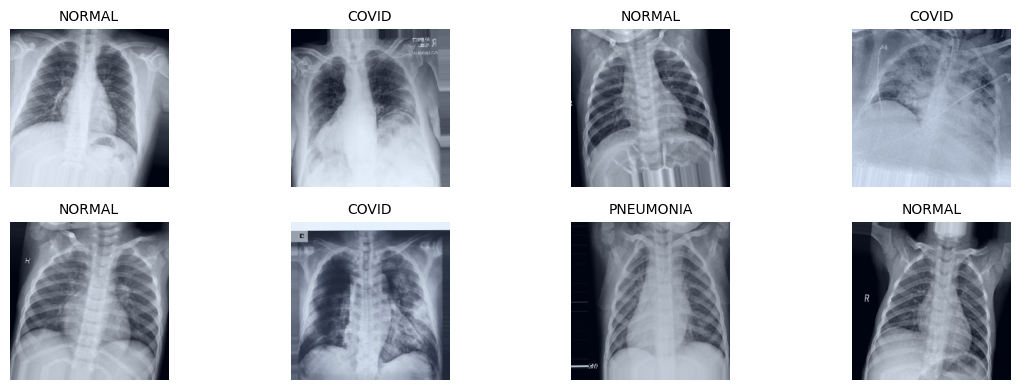

In [5]:
x_batch, y_batch = next(train_gen)

plt.figure(figsize=(12, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    img = x_batch[i]
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)  
    plt.imshow(img)
    label_idx = np.argmax(y_batch[i])
    plt.title(idx_to_class[label_idx], fontsize=10)
    plt.axis("off")
plt.tight_layout()
plt.show()

train_gen.reset()

## 6. Build DenseNet121 model

In [6]:
base_model = DenseNet121(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Phase 1: freeze base

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

I0000 00:00:1787596234.778239      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,300,675 (27.85 MB)

 Trainable params: 263,171 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

## 7. Phase 1 — Train with frozen base

In [7]:
checkpoint_cb1 = ModelCheckpoint(
    "best_model_phase1.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)
early_stop_cb = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
reduce_lr_cb = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=[checkpoint_cb1, early_stop_cb, reduce_lr_cb],
)

Epoch 1/15
  2/131 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.4844 - loss: 1.3356    

I0000 00:00:1787596270.595071      86 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 0.8042 - loss: 0.4689
Epoch 1: val_accuracy improved from None to 0.95215, saving model to best_model_phase1.keras

Epoch 1: finished saving model to best_model_phase1.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 142s 857ms/step - accuracy: 0.8774 - loss: 0.3139 - val_accuracy: 0.9522 - val_loss: 0.1662 - learning_rate: 0.0010
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.9259 - loss: 0.1969
Epoch 2: val_accuracy improved from 0.95215 to 0.95981, saving model to best_model_phase1.keras

Epoch 2: finished saving model to best_model_phase1.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 56s 426ms/step - accuracy: 0.9311 - loss: 0.1897 - val_accuracy: 0.9598 - val_loss: 0.1282 - learning_rate: 0.0010
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.9367 - loss: 0.1730
Epoch 3: val_accuracy did not improve from 0.95981
131/131 ━━━━━━━━━━━━━━━━━━━━ 53s 404ms/step - accuracy: 0.9371 - loss: 0.1737 - val_accuracy: 0.9483

## 8. Phase 2 — Fine-tune (unfreeze last block)

In [8]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

checkpoint_cb2 = ModelCheckpoint(
    "best_model.keras",   
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=[checkpoint_cb2, early_stop_cb, reduce_lr_cb],
)

Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.3796 - loss: 3.8779
Epoch 1: val_accuracy improved from None to 0.94258, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 125s 711ms/step - accuracy: 0.4743 - loss: 2.8087 - val_accuracy: 0.9426 - val_loss: 0.1703 - learning_rate: 1.0000e-05
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.6877 - loss: 1.2582
Epoch 2: val_accuracy did not improve from 0.94258
131/131 ━━━━━━━━━━━━━━━━━━━━ 52s 400ms/step - accuracy: 0.7499 - loss: 0.9253 - val_accuracy: 0.9426 - val_loss: 0.1815 - learning_rate: 1.0000e-05
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.8390 - loss: 0.5431
Epoch 3: val_accuracy improved from 0.94258 to 0.94833, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 53s 407ms/step - accuracy: 0.8468 - loss: 0.5234 - val_accuracy: 0.9483 - val_lo

## 9. Training curves

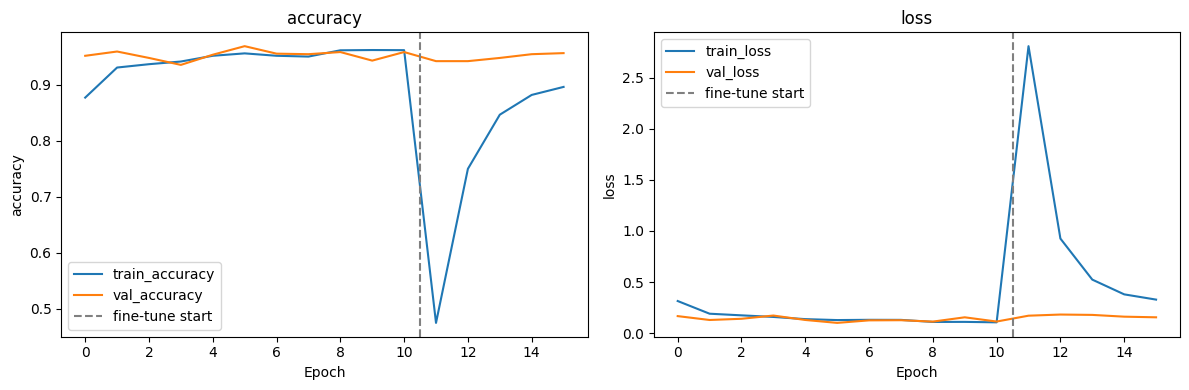

In [9]:
def plot_history(h1, h2, metric):
    vals = h1.history[metric] + h2.history[metric]
    val_vals = h1.history[f"val_{metric}"] + h2.history[f"val_{metric}"]
    plt.plot(vals, label=f"train_{metric}")
    plt.plot(val_vals, label=f"val_{metric}")
    plt.axvline(x=len(h1.history[metric]) - 0.5, color="gray", linestyle="--", label="fine-tune start")
    plt.xlabel("Epoch"); plt.ylabel(metric); plt.legend(); plt.title(metric)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plot_history(history1, history2, "accuracy")
plt.subplot(1, 2, 2)
plot_history(history1, history2, "loss")
plt.tight_layout()
plt.show()

## 10. Save API artifacts

In [10]:
api_config = {
    "class_indices": class_indices,
    "idx_to_class": idx_to_class,
    "img_size": list(IMG_SIZE),
    "preprocessing": "densenet_preprocess_input",
    "model_architecture": "DenseNet121",
    "input_shape": [224, 224, 3],
}

with open("model_config.json", "w") as f:
    json.dump(api_config, f, indent=2)

print(json.dumps(api_config, indent=2))

{
  "class_indices": {
    "COVID": 0,
    "NORMAL": 1,
    "PNEUMONIA": 2
  },
  "idx_to_class": {
    "0": "COVID",
    "1": "NORMAL",
    "2": "PNEUMONIA"
  },
  "img_size": [
    224,
    224
  ],
  "preprocessing": "densenet_preprocess_input",
  "model_architecture": "DenseNet121",
  "input_shape": [
    224,
    224,
    3
  ]
}


## 11. Evaluate best model

In [11]:
best_model = load_model("best_model.keras")

val_gen.reset()
preds = best_model.predict(val_gen)
y_pred = np.argmax(preds, axis=1)
y_true = val_gen.classes

class_names = [idx_to_class[i] for i in range(NUM_CLASSES)]

print(classification_report(y_true, y_pred, target_names=class_names))

test_loss, test_acc = best_model.evaluate(val_gen)
print(f"Validation Accuracy: {test_acc:.4f}")

33/33 ━━━━━━━━━━━━━━━━━━━━ 27s 474ms/step
              precision    recall  f1-score   support

       COVID       0.96      1.00      0.98       325
      NORMAL       0.93      0.97      0.95       360
   PNEUMONIA       0.99      0.91      0.94       360

    accuracy                           0.96      1045
   macro avg       0.96      0.96      0.96      1045
weighted avg       0.96      0.96      0.96      1045

33/33 ━━━━━━━━━━━━━━━━━━━━ 27s 361ms/step - accuracy: 0.9569 - loss: 0.1545
Validation Accuracy: 0.9569


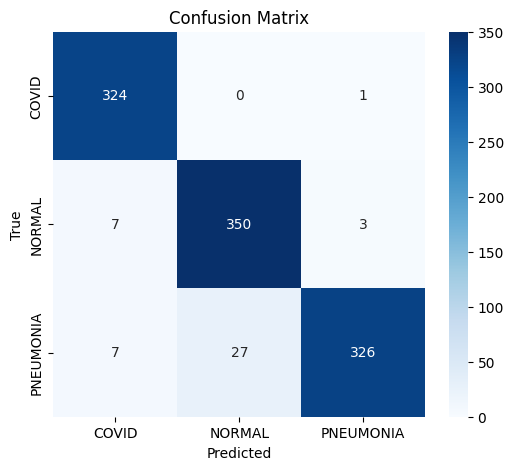

In [12]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
plt.show()

## 12. Grad-CAM

In [13]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name="conv5_block16_2_conv"):
    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output],
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(class_idx)


def display_gradcam(img_path, model, img_size=(224, 224), alpha=0.4):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_input = preprocess_input(np.expand_dims(img_array, axis=0))

    heatmap, class_idx = get_gradcam_heatmap(model, img_input)
    heatmap = cv2.resize(heatmap, img_size)
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed = heatmap_color * alpha + img_array
    superimposed = np.uint8(np.clip(superimposed, 0, 255))

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_array.astype("uint8")); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(superimposed); axes[1].set_title(f"Grad-CAM: {idx_to_class[class_idx]}"); axes[1].axis("off")
    plt.show()


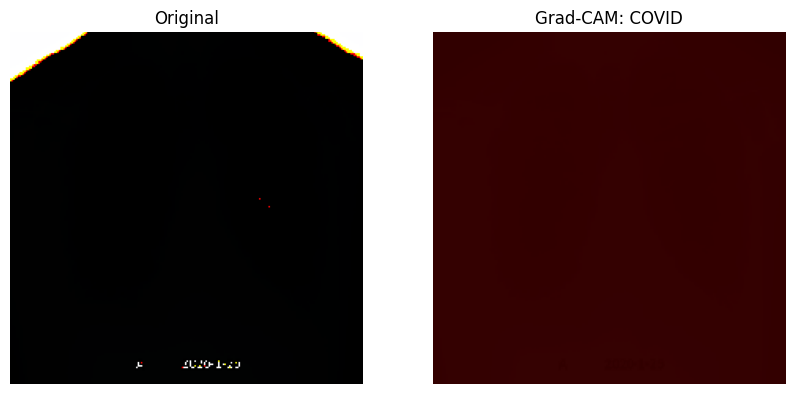

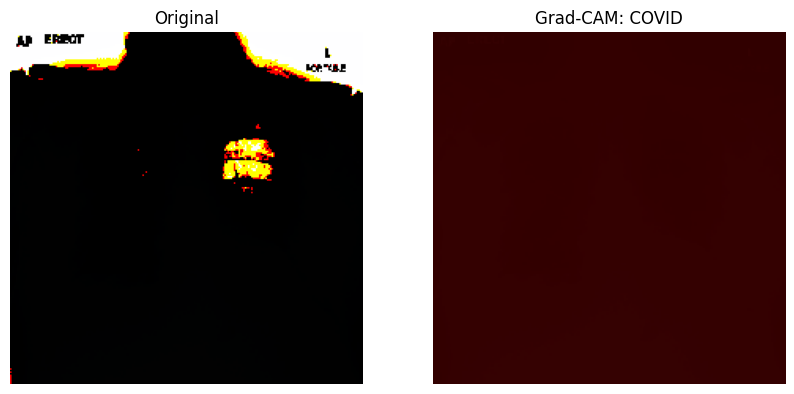

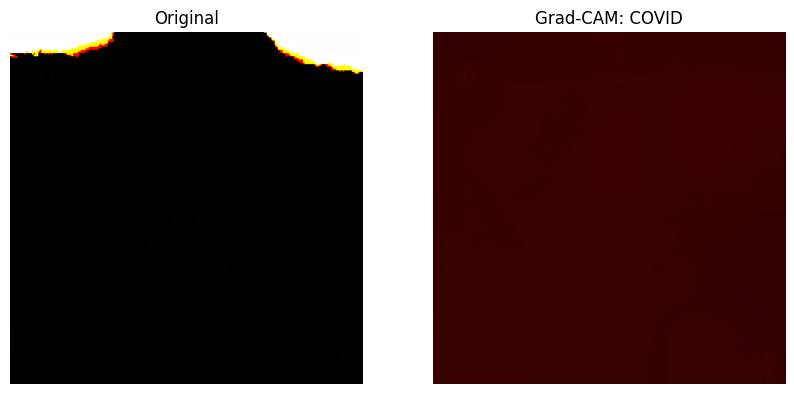

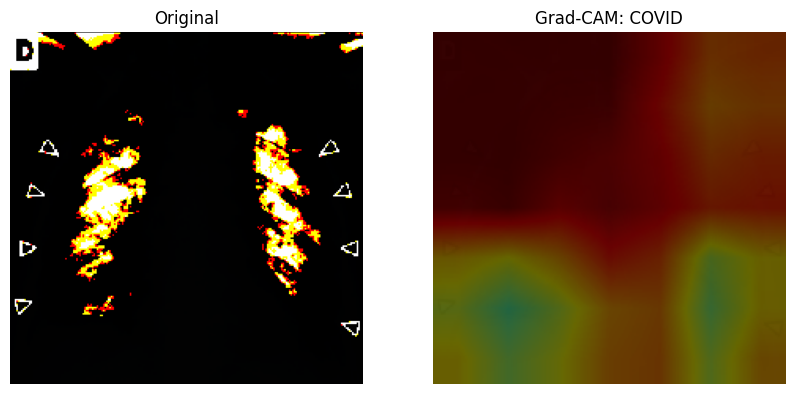

In [14]:
import random as _random

sample_paths = _random.sample(val_gen.filepaths, 4)
for p in sample_paths:
    display_gradcam(p, best_model)